## Projeto 2: Detecção de Anomalia para Realização de Manutenção Preventiva
**Disciplina:** Estatística e Probabilidade para Computação - 2026.1


### Seção 1: Introdução

#### 1.1 Contextualização
A manutenção preventiva visa antecipar falhas em equipamentos industriais, reduzindo custos com paradas não programadas. Em ambientes de manufatura modernos, sensores coletam dados operacionais continuamente. No entanto, identificar o momento exato em que o desgaste natural se torna um risco de falha exige rigor estatístico. 

#### 1.2 Objetivo
O objetivo principal desta análise é identificar anomalias nos parâmetros operacionais (temperatura, velocidade rotacional, torque e desgaste da ferramenta) que precedem os diferentes modos de falha da máquina (TWF, HDF, PWF, OSF, RNF). A pergunta central é: **Podemos detectar padrões estatisticamente anômalos que indicam uma falha iminente antes que ela ocorra?**

#### 1.3 Descrição dos Dados
O dataset utilizado é o `ai4i2020.csv`, composto por 10.000 registros e 14 variáveis. As variáveis principais incluem características de qualidade do produto (L, M, H), medições contínuas de sensores (temperatura do ar e do processo, velocidade rotacional, torque e desgaste da ferramenta) e uma variável alvo binária (`machine failure`), além de cinco variáveis indicadoras para modos de falha específicos.

### Seção 2: EDA

,UDI,Product.ID,Type,Air.temperature..K.,Process.temperature..K.,Rotational.speed..rpm.,Torque..Nm.,Tool.wear..min.,Machine.failure,TWF,HDF,PWF,OSF,RNF
,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
2,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
3,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
4,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
5,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


'data.frame':	10000 obs. of  14 variables:
 $ UDI                    : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Product.ID             : chr  "M14860" "L47181" "L47182" "L47183" ...
 $ Type                   : chr  "M" "L" "L" "L" ...
 $ Air.temperature..K.    : num  298 298 298 298 298 ...
 $ Process.temperature..K.: num  309 309 308 309 309 ...
 $ Rotational.speed..rpm. : int  1551 1408 1498 1433 1408 1425 1558 1527 1667 1741 ...
 $ Torque..Nm.            : num  42.8 46.3 49.4 39.5 40 41.9 42.4 40.2 28.6 28 ...
 $ Tool.wear..min.        : int  0 3 5 7 9 11 14 16 18 21 ...
 $ Machine.failure        : int  0 0 0 0 0 0 0 0 0 0 ...
 $ TWF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ HDF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ PWF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ OSF                    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ RNF                    : int  0 0 0 0 0 0 0 0 0 0 ...


UDI              Product.ID                    Type 
                      0                       0                       0 
    Air.temperature..K. Process.temperature..K.  Rotational.speed..rpm. 
                      0                       0                       0 
            Torque..Nm.         Tool.wear..min.         Machine.failure 
                      0                       0                       0 
                    TWF                     HDF                     PWF 
                      0                       0                       0 
                    OSF                     RNF 
                      0                       0

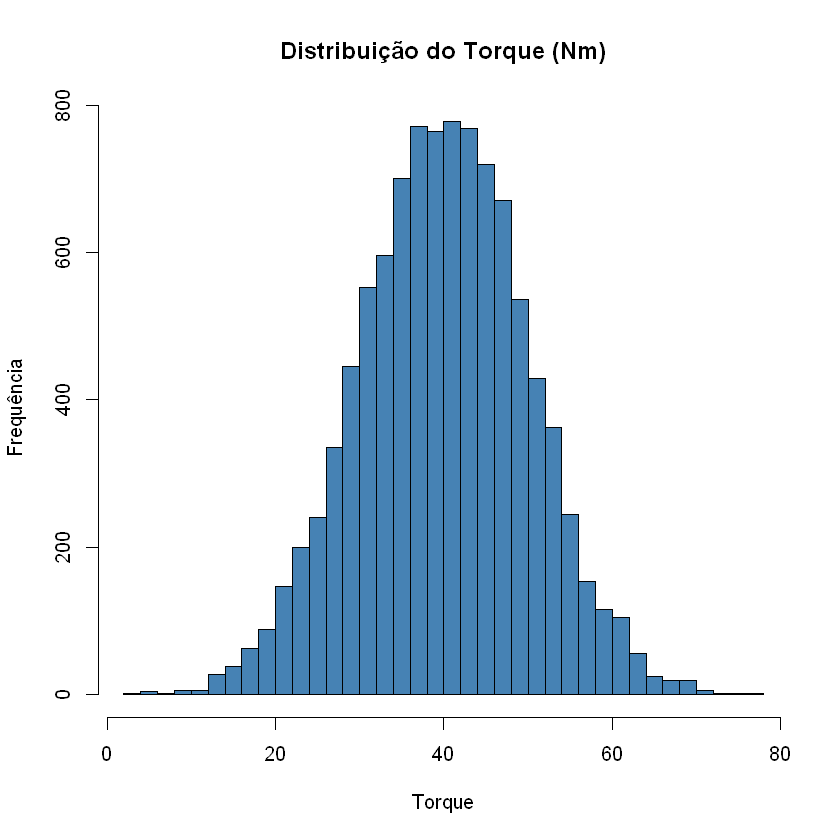

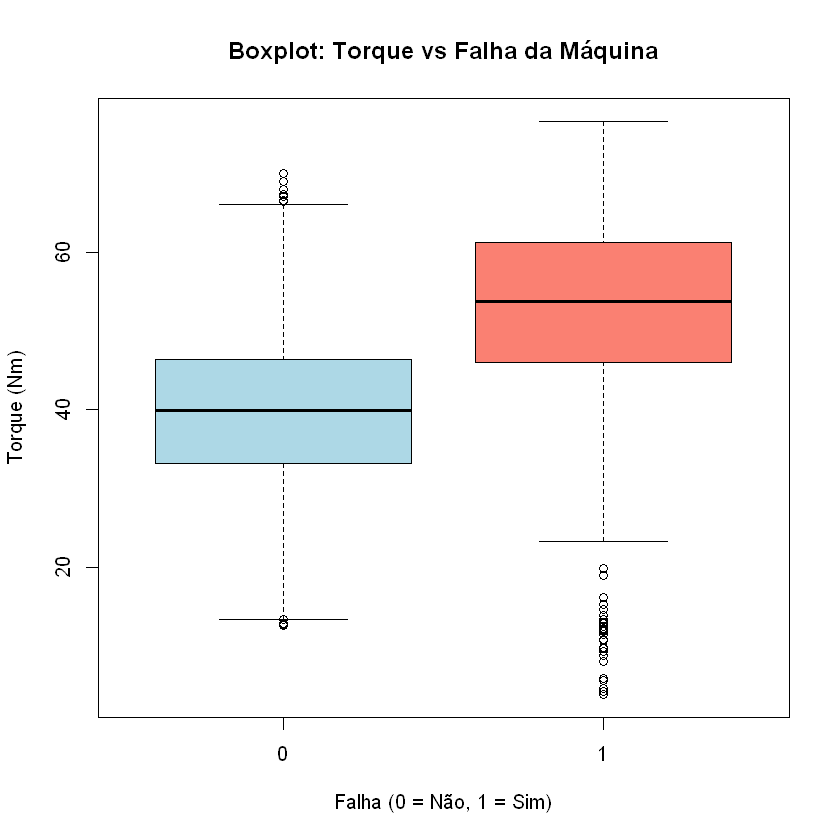

In [1]:
df <- read.csv("ai4i2020.csv")

# Visualizando as primeira linhas do dataset
head(df, 5)

# Verificação do tipo de dados
str(df)

# Checando valores nulos
colSums(is.na(df))


# 2.2 Análise Univariada
# Histograma para a variável Torque
hist(df$Torque..Nm., 
     breaks = 30, 
     col = "steelblue", 
     border = "black",
     main = "Distribuição do Torque (Nm)", 
     xlab = "Torque", 
     ylab = "Frequência")

# Boxplot para visualizar a dispersão e outliers do Torque em relação às falhas
boxplot(Torque..Nm. ~ Machine.failure, data = df,
        col = c("lightblue", "salmon"),
        main = "Boxplot: Torque vs Falha da Máquina",
        xlab = "Falha (0 = Não, 1 = Sim)",
        ylab = "Torque (Nm)")